#  Проект. Прогнозирование заказов такси

## Введение

Сервисы такси сталкиваются с высокой динамикой спроса, особенно вблизи аэропортов и в часы пиковой нагрузки. Эффективное планирование ресурсов, включая распределение водителей, требует точного прогнозирования количества заказов. Прогнозирование количества заказов такси позволит своевременно реагировать на рост спроса, оптимизировать загрузку водителей и повысить качество обслуживания клиентов.

## Цель проекта

Построить модель для прогнозирования количества заказов такси на следующий час. <br>
Значение метрики RMSE на тестовой выборке должно быть не больше 48.

## Описание данных

Данные представляют собой историческую информацию о заказах такси в аэропортах.

Признаки:
* datetime — дата и время заказа;
* num_orders — количество заказов за указанный временной интервал.

## План выполнения проекта

* [Загрузка данных](#link1)
* [Предобработка данных](#link2)
* [Анализ данных](#link3)
* [Построение моделей](#link4)
* [Оценка лучшей модели](#link5)
* [Общий вывод](#link6)

## Подготовка рабочего пространства

In [1]:
# установим необхождимые библиотеки
!pip install lightgbm

# импортируем необходимые библиотеки
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from lightgbm import LGBMRegressor

# Импортируем мой модуль для DS
import ds_lib_tatarnikov as mylib

# зададим константы
RANDOM_STATE = 42

# настройки отображения таблиц
pd.options.display.max_columns = None

<a class='anchor' id="link1"></a>
## 1 Загрузка данных

**1.1 Откроем файл с данными**

In [2]:
try:
    df = pd.read_csv('taxi.csv', index_col=[0], parse_dates=[0])
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', index_col=[0], parse_dates=[0])

df.sort_index(inplace=True) # сразу отсортируем по дате

**1.2 Изучим общую информацию о датафрейме**

Выведем первые строки и общую информацию о датафрейме.

In [3]:
mylib.data_overview(df, 'с данными о заказах такси', index_col=True)

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB

Таблица с данными о заказах такси состоит из 26496 строк и 2 столбцов, один из которых используется как индексный.
Пропусков нет.


**Промежуточный итог:**<br>
Данные успешно загружены. Изучена общая информация о предоставленной таблице.

<a class='anchor' id="link2"></a>
## 2 Предобработка данных

Проверим данные на монотонность.

In [4]:
df.index.is_monotonic

True

Данные правильно отсортированы. Можно приступать к обработке и анализу.

Проведем ресемплирование данных по одному часу.

In [5]:
df = df.resample('1H').sum()
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


**Промежуточный итог:**<br>
Данные сгруппированы по часам.

<a class='anchor' id="link3"></a>
## 3 Анализ данных

Посмотрим статистическое описание данных.

In [6]:
df.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


Построим график заказов.

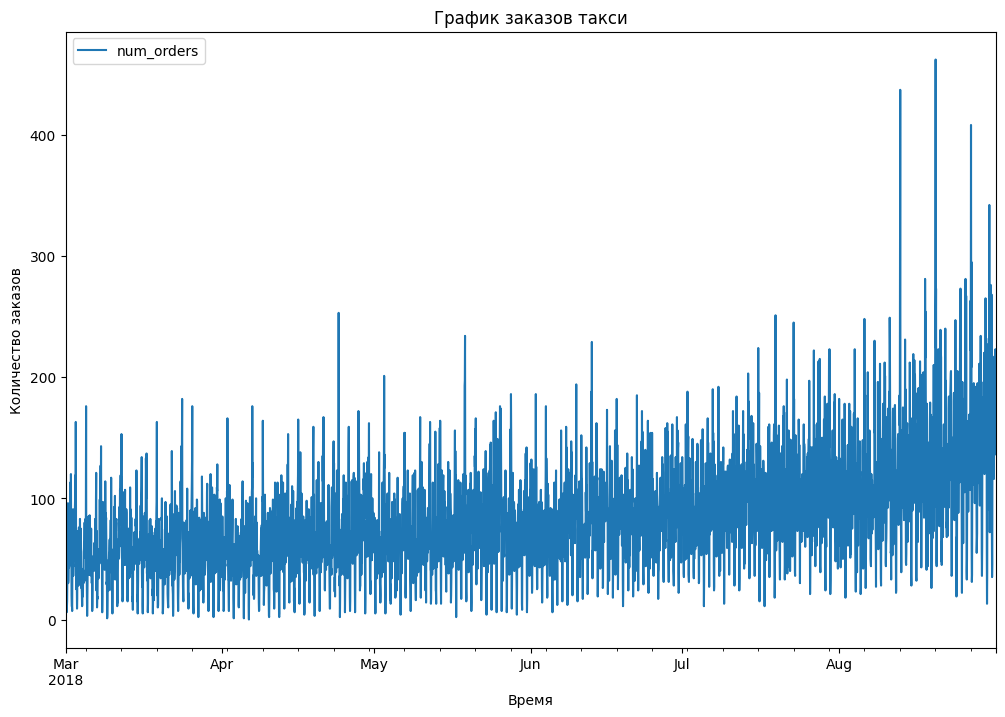

In [7]:
df.plot(figsize=(12,8))
plt.xlabel('Время')
plt.ylabel('Количество заказов')
plt.title('График заказов такси')
plt.legend()
plt.show()

Видно, что в таблице представлена информация о заказах за период с матра по август 2018 года. Данные не страционарные: разброс и среднее значение увеличиваются к концу периода.

Посмотрим на основные статистические характеристики временного ряда.

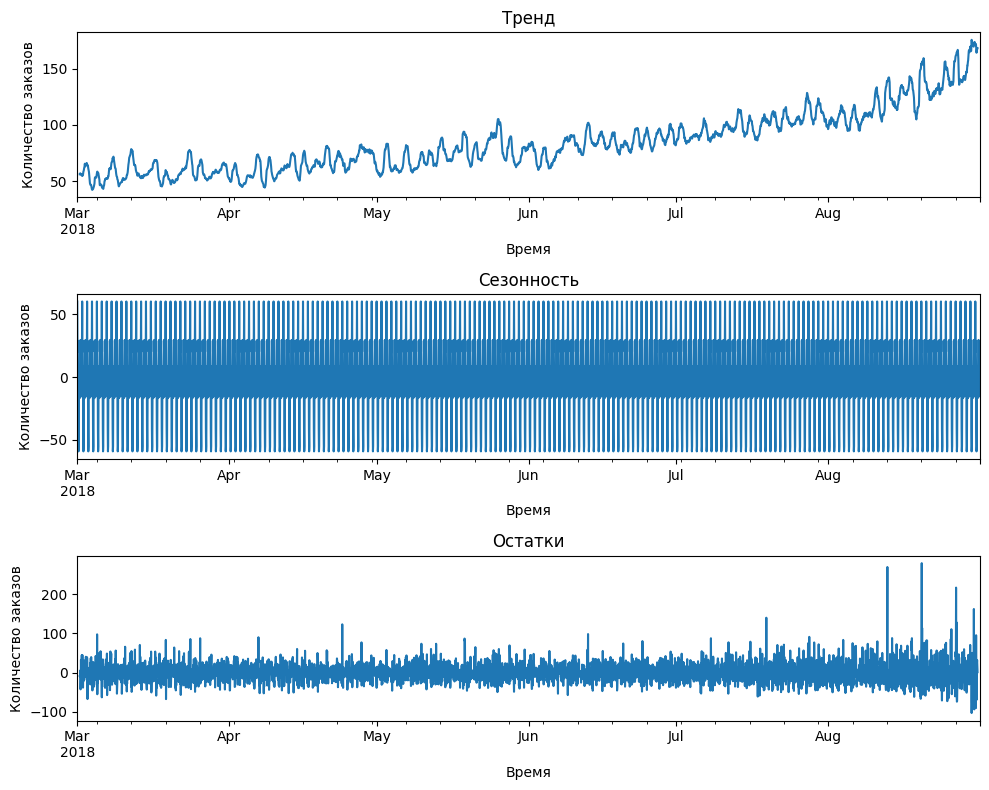

In [8]:
decomposed = seasonal_decompose(df)
plt.figure(figsize=(10, 8))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Тренд')
plt.xlabel('Время')
plt.ylabel('Количество заказов')

plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Сезонность')
plt.xlabel('Время')
plt.ylabel('Количество заказов')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Остатки')
plt.xlabel('Время')
plt.ylabel('Количество заказов')

plt.tight_layout()

Имеется тренд на увеличение количества заказов. Тренд ускоряется к концу наблюдаемого периода. 

График остатков колеблются около нуля. Имеются всплески остатков, которые не учитываются ни трендом ни сезонностью.

Величина остатков и количество всплесков становится больше к концу периода наблюдения. Так как при делении мы не перемешиваем данные, в обучающаю выборку попадут данные с низкими отстатками, а в тестовую часть - данные с бо́льшими остатками и выбросами. <br>
Это приведет к тому что, RMSE на тестовой выборке будет хуже, чем RMSE при кросс-валидаиции.

Посмортим на график сезонности в большем масштабе. Возьмем информацию за первую неделю.

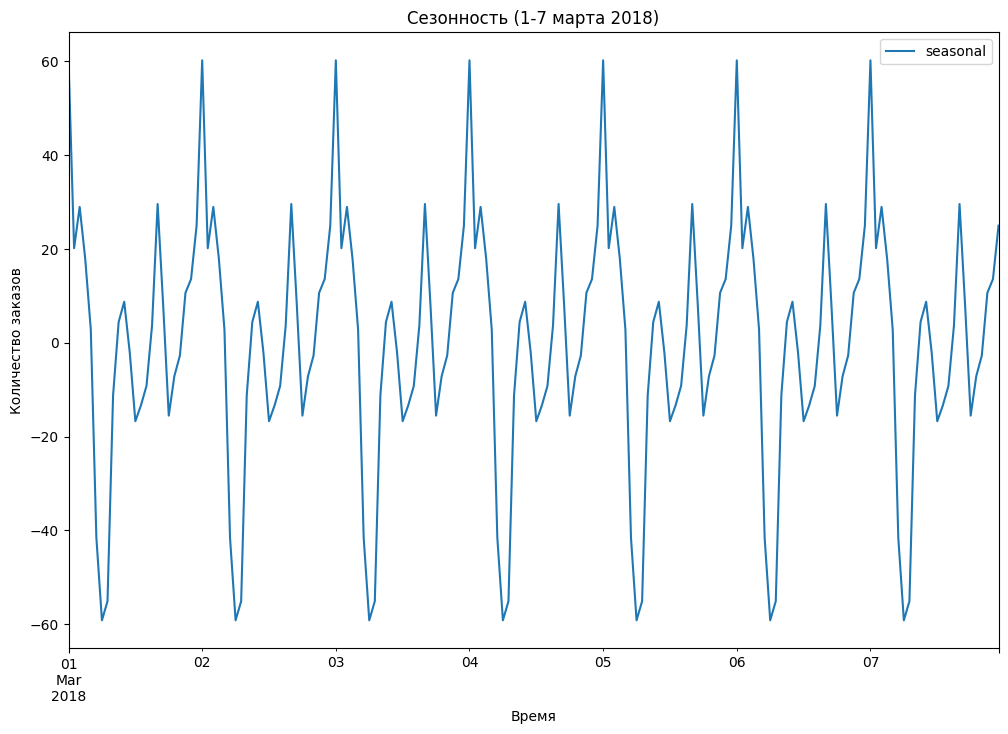

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))
decomposed.seasonal['2018-03-01':'2018-03-07'].plot()
ax.set_title('Сезонность (1-7 марта 2018)')
ax.set_xlabel('Время')
ax.set_ylabel('Количество заказов')
ax.legend()
plt.show()

Есть дневная сезонность в количестве заказов такси. Имеется три пиковых часа утром днем и вечером. В ночные часы заказов меньше.

Вычислим разность временного ряда. Вычтем для каждого часа количество заказов за этот час сутки назад.

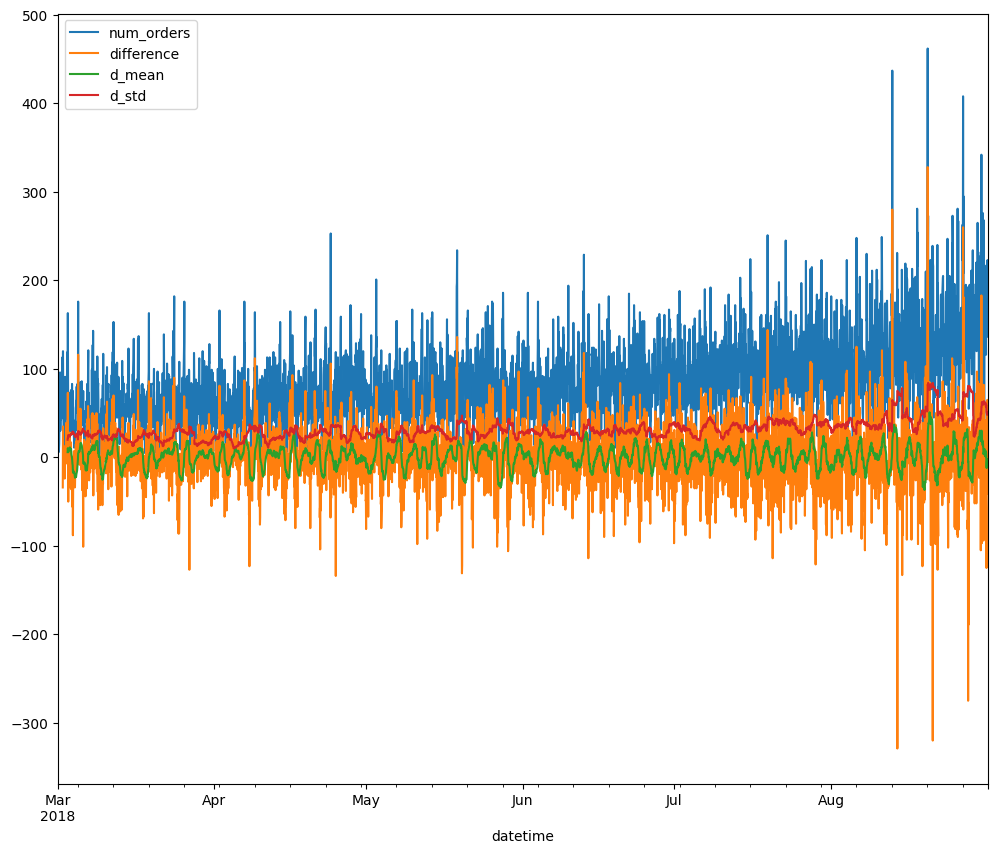

In [10]:
df['difference'] = df['num_orders'] - df['num_orders'].shift(24)
df['d_mean'] = df['difference'].rolling(24).mean()
df['d_std'] = df['difference'].rolling(24).std()
df.plot(figsize=(12,10))
plt.show()

Графики стали более стационарны.

Cделаем ресемплирование по дням и посмотрим статистические характеристики.

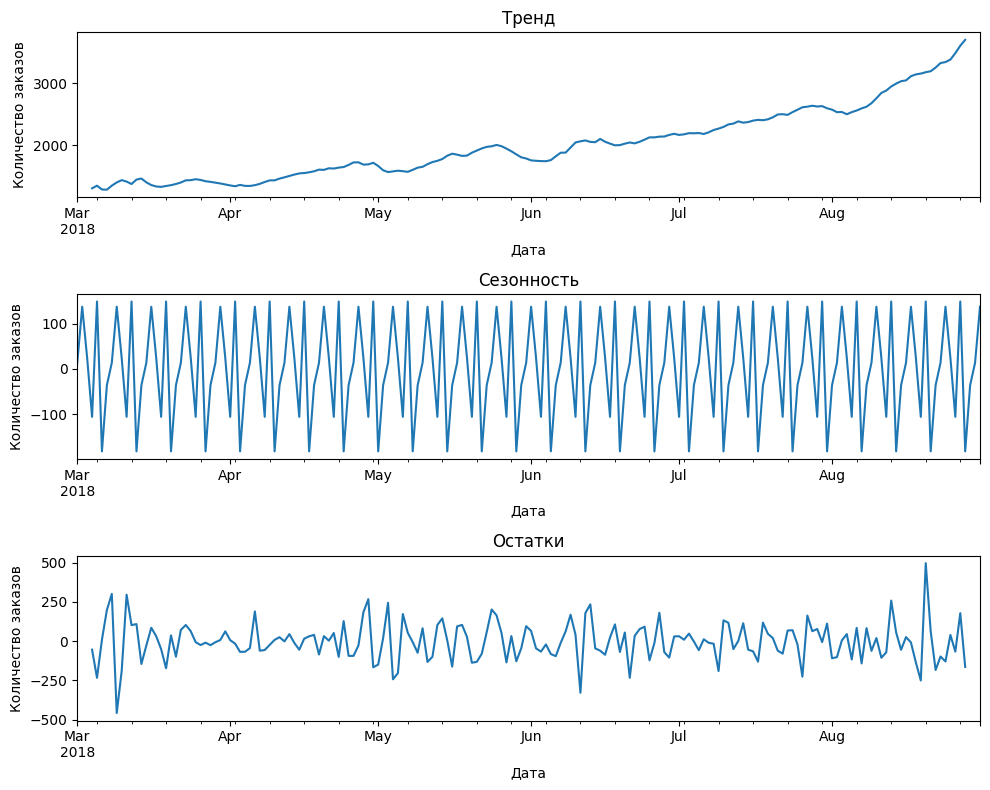

In [11]:
df_daily = df.resample('1D').sum()
df_daily.head()

decomposed = seasonal_decompose(df_daily['num_orders'], period=7)
plt.figure(figsize=(10, 8))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Тренд')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Сезонность')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Остатки')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.tight_layout()

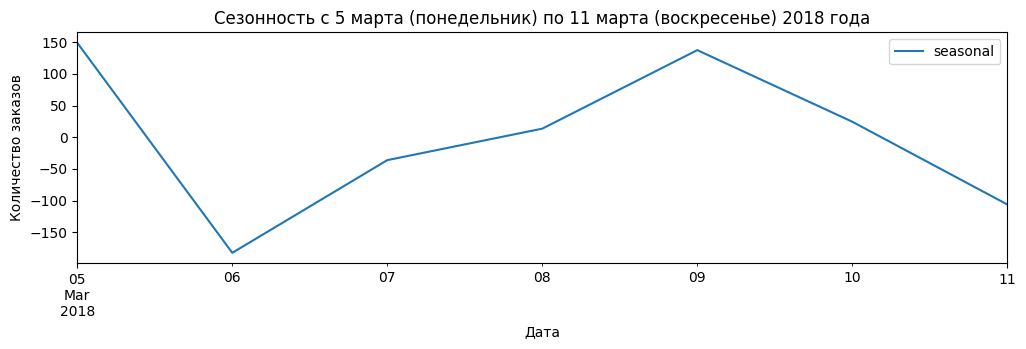

In [12]:
# посмотрим на недельную сезонность 
fig, ax = plt.subplots(figsize=(12, 3))
decomposed.seasonal['2018-03-05':'2018-03-11'].plot()
ax.set_title('Сезонность с 5 марта (понедельник) по 11 марта (воскресенье) 2018 года')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество заказов')
ax.legend()
plt.show()

График тренда стал ровнее. Все недельные колебания теперь учтены в графике недельной сезонности. График остатков в дневном масштабе имеет меньше всплесков.

**Промежуточный итог:**<br>
Для анализа предоставлены данные о заказах такси за период с марта по август 2018 года. График не стационарен и имеет восходящий тренд. Имеется четко выраженная сезонность в количестве заказов такси: дневная и недельная.

<a class='anchor' id="link4"></a>
## 4 Построение моделей

Создадим новые признаки.

In [13]:
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek
df['hour'] = df.index.hour

# Добавим почасовые логи в течение суток
for lag in range(1, 24):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)
    
# Добавим дневные лаги в течение недели
for lag in range(24, 24 * 7 + 1, 24):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)

# Добавим скользящее среднее за сутки
df['rolling_mean'] = df['num_orders'].shift().rolling(24).mean()

df.head()

,num_orders,difference,d_mean,d_std,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_48,lag_72,lag_96,lag_120,lag_144,lag_168,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,NaN,NaN,NaN,1,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,NaN,NaN,NaN,1,3,1,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,NaN,NaN,NaN,1,3,2,85.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,NaN,NaN,NaN,1,3,3,71.0,85.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,NaN,NaN,NaN,1,3,4,66.0,71.0,85.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
features = list(df.columns)
for col in ['num_orders', 'difference', 'd_mean', 'd_std']:
    features.remove(col)
target_feature = 'num_orders'

# cписок признаков для обучения
features

['day',
 'dayofweek',
 'hour',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_4',
 'lag_5',
 'lag_6',
 'lag_7',
 'lag_8',
 'lag_9',
 'lag_10',
 'lag_11',
 'lag_12',
 'lag_13',
 'lag_14',
 'lag_15',
 'lag_16',
 'lag_17',
 'lag_18',
 'lag_19',
 'lag_20',
 'lag_21',
 'lag_22',
 'lag_23',
 'lag_24',
 'lag_48',
 'lag_72',
 'lag_96',
 'lag_120',
 'lag_144',
 'lag_168',
 'rolling_mean']

Подготовим к обучению датафрейм.

In [15]:
df_prepared = df[features + [target_feature]].copy()
df_prepared.dropna(inplace=True)

In [16]:
df_prepared.head()

,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_48,lag_72,lag_96,lag_120,lag_144,lag_168,rolling_mean,num_orders
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,8,3,0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,66.0,24.0,121.0,100.0,42.0,86.0,75.0,163.0,90.0,124.0,60.041667,143
2018-03-08 01:00:00,8,3,1,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,66.0,24.0,121.0,75.0,176.0,60.0,108.0,120.0,85.0,61.833333,78
2018-03-08 02:00:00,8,3,2,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,66.0,24.0,36.0,32.0,26.0,25.0,75.0,71.0,60.041667,65
2018-03-08 03:00:00,8,3,3,65.0,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,66.0,49.0,51.0,42.0,64.0,64.0,66.0,61.750000,68
2018-03-08 04:00:00,8,3,4,68.0,65.0,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,30.0,34.0,27.0,44.0,20.0,43.0,61.833333,60


Разделим данные на тренировочную, валидационную и тестовые выборки.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df_prepared.drop(target_feature, axis=1),
    df_prepared[target_feature],
    test_size = 0.1, 
    shuffle=False,
    random_state = RANDOM_STATE
)

Создадим пайплайн для перебора моделей и гиперпараметров.

In [18]:
# Pipeline
pipe_final = Pipeline([
    ('model', LinearRegression())
])

In [19]:
# Создадим сетку для перебора моделей и гиперпараметров
param_grid = [
    {
        'model': [LinearRegression()],
        'model__fit_intercept': [True, False]
    },
    {
        'model': [RandomForestRegressor(random_state=42)],
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    {
        'model': [LGBMRegressor(random_state=42, verbose=-1)],
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.3],
        'model__num_leaves': [31, 50, 70]
    }
]

In [20]:
# Настройка GridSearchCV
grid = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Обучение
grid.fit(X_train, y_train)

# Вывод результатов
print('Лучшая модель и её параметры:\n\n', grid.best_estimator_)
print(f'\nМетрика RMSE лучшей модели (на кросс-валидации): {-grid.best_score_:.2f}')

Лучшая модель и её параметры:

 Pipeline(steps=[('model', LinearRegression(fit_intercept=False))])

Метрика RMSE лучшей модели (на кросс-валидации): 22.11


**Промежуточный итог:**<br>
Данные подготовлены к обучению, были созданы новые признаки. Было проведено обучение моделей LinearRegression, RandomForestRegressor и LGBMRegressor, произведен перебор их гиперпараметров. Лучшей моделью оказалась LinearRegression с метрикой RMSE 22.11 на кросс-валидации.

<a class='anchor' id="link5"></a>
## 5 Оценка лучшей модели

Оценим качество лучшей модели на тестовой выборке.

In [21]:
y_pred = grid.best_estimator_.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nRMSE на тестовых данных: {rmse:.2f}")


RMSE на тестовых данных: 34.75


**Промежуточный итог:**<br>
RMSE лучшей модели на тестовых данных 34.75, что удовлетворяет целевому RMSE не более 48.

<a class='anchor' id="link6"></a>
## Общий вывод

Целью проекта было построение модели для прогнозирования количества заказов такси на следующий час на основе исторических данных сервиса такси за период с марта по август 2018 года. Требовалось достичь значения метрики RMSE на тестовой выборке не более 48.

Данные были проанализированы. Обнаружено, что временной ряд нестационарен, имеет восходящий тренд и выраженную дневную сезонность.

Для подготовки данных созданы новые признаки, учитывающие дату, месяц, день недели и время заказа такси. Также в каждую запись была добавлена информация о заказах такси в это же время день назад и неделю назад.

Были обучены несколько моделей. Лучшей оказалась LinearRegression.
RMSE на тестовой выборке 34.75 заказов, что удовлетворяет целевому порогу 48.

Модель успешно прогнозирует количество заказов на следующий час.